# Práctica 2: Perceptrón

## Ejercicio 1

El archivo **Hawks.csv** contiene mediciones de casi 900 aves de tres especies diferentes. Los datos registrados son los siguientes:  
- **Epecies.** Es la etiqueta de clase e indica la especie de cada gavilán: gavilanes de Cooper (CH), gavilanes colirrojos (RT) y gavilanes rastreros (SS).
- **Año.** Indica el año en que se avistó el ave.
- **Hallux.** Indica la medida en milímetros del hallux (el dedo posterior del pie, que poseen todas las aves cazadoras para sujetar mejor a sus presas).
- **Ala.** Indica la longitud en milímetros de la pluma más larga del ala.
- **Peso.** Indica el peso del ave en gramos.
- **Cola.** Indica la longitud de la cola del ave en milímetros.

1. Calcule la correlación lineal entre los atributos **Ala** y **Cola**. Indique la intensidad de la correlación (no hay correlación/débil/fuerte) y el tipo (positiva/negativa)

| Categorías | Análisis |
|-------|--|
| Valor | 0.8998883674343948 |
| Intensidad | Fuerte. $|Corr(A, B)| \geq 0.8$ |
| Tipo | Positiva. Cuando crece el valor de Ala, también crece el valor de Cola |

2. Complete el cuadro con los valores del atributo **Hallux** antes y después de normalizarlos utilizando media y desvío.

| Medida | Sin Normalizar | Normalizado |
|--------|----------------|-------------|
| Media | 295 | 0.01 |
| Desvio | 321.32 | 1.0005 |
| Mínimo | 95 | -0.61 |
| Q1 | 152 | -0.43 |
| Q2 | 295 | 0.01 |
| Q3 | 315 | 0.07 |
| RIC | 163 | 0.50 |
| Máximo | 3414 | 9.72 |
| Bigote Inferior | 95 | -0.61 |
| Bigote Superior | 545 | 0.78 |

Compare los valores obtenidos e indique el valor de verdad de las siguientes afirmaciones: 
1. El valor de Q2 normalizado permite afirmar que la media y la mediana tienen valores cercanos.
2. El máximo valor de Hallux se encuentra a más de 9 desvíos por encima de la media.
3. Un hallux que mida más de 600 mm es considerado atípico extremo.
4. Un valor normalizado del atributo “hallux” de 2 se considerará un valor atípico extremo.
5. En un gavilán es atípico que su hallux mida menos de 100 mm.

### Respuestas

1. **VERDADERO**. Al normalizar con Standard en mi caso, nos da que la media y la mediana tienen valores cercanos.
2. **VERDADERO**. Si calculamos 9 desviós el valor que nos da es $2891.88$, el máximo supera ese valor.
3. **FALSO**. Para ser atípico extremo se tiene que superar el valor $804 = Q3 + 3 * RIC$
4. **VERDADERO**. Para ser atípico extremo se debería de superar el valor aprox. de $1.57 \rightarrow Q3 + 3 * RIC$
5. **FALSO**. Para ser atípico debería de ser menor que 95.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# nos traemos el csv
df_hawks = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\hawks.csv",
                 delimiter=";",
                 encoding="latin-1"
)

# chequeamos que esté bien
print(df_hawks.head())    # vemos las primeras filas
df_hawks.shape    # vemos cantidad de filas y columnas
df_hawks.info()     # vemos tipos de datos
df_hawks.describe() # vemos estadísticas de las columnas numéricas
nulos = df_hawks.isnull().sum()
porcentaje_nulos = (df_hawks.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)
print("--------------------CORRELACION ENTRE ALA Y COLA--------------------")
print(df_hawks["Ala"].corr(df_hawks["Cola"]))
print("--------------------VALORES SIN NORMALIZAR--------------------")
min = df_hawks["Hallux"].min()
max = df_hawks["Hallux"].max()
stddev = df_hawks["Hallux"].std()
media = df_hawks["Hallux"].median()
q1 = df_hawks["Hallux"].quantile(0.25)
q2 = df_hawks["Hallux"].quantile(0.5)
q3 = df_hawks["Hallux"].quantile(0.75)
ric = q3 - q1
valor_big_sup = df_hawks["Hallux"][(df_hawks["Hallux"] <= (q3 + 1.5 * ric))].max()
valor_big_inf = df_hawks["Hallux"][(df_hawks["Hallux"] >= (q1 - 1.5 * ric))].min()
print("Mínimo: ", min)
print("Máximo: ", max)
print("Desviación Standard: ", stddev)
print("Media: ", media)
print("Q1: ", q1)
print("Q2: ", q2)
print("Q3: ", q3)
print("RIC: ", ric)
print("Bigote Inferior: ", valor_big_inf)
print("Bigote Superior: ", valor_big_sup)
print("--------------------VALORES NORMALIZADOS--------------------")
scaler = StandardScaler()
df_hawks["Hallux_Norm"] = scaler.fit_transform(df_hawks[["Hallux"]])
min = df_hawks["Hallux_Norm"].min()
max = df_hawks["Hallux_Norm"].max()
stddev = df_hawks["Hallux_Norm"].std()
media = df_hawks["Hallux_Norm"].median()
q1 = df_hawks["Hallux_Norm"].quantile(0.25)
q2 = df_hawks["Hallux_Norm"].quantile(0.5)
q3 = df_hawks["Hallux_Norm"].quantile(0.75)
ric = q3 - q1
valor_big_sup = df_hawks["Hallux_Norm"][(df_hawks["Hallux_Norm"] <= (q3 + 1.5 * ric))].max()
valor_big_inf = df_hawks["Hallux_Norm"][(df_hawks["Hallux_Norm"] >= (q1 - 1.5 * ric))].min()
print("Mínimo: ", min)
print("Máximo: ", max)
print("Desviación Standard: ", stddev)
print("Media: ", media)
print("Q1: ", q1)
print("Q2: ", q2)
print("Q3: ", q3)
print("RIC: ", ric)
print("Bigote Inferior: ", valor_big_inf)
print("Bigote Superior: ", valor_big_sup)

    Año Especie   Ala   Peso  Cola  Hallux
0  1994      RT  2770   9400   218     304
1  1997      RT  3730   9140   221     304
2  2000      RT  3790  10000   217     322
3  2000      RT  3920  11850   229     330
4  2002      RT  3650  11250   213     293
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Año      893 non-null    int64 
 1   Especie  893 non-null    object
 2   Ala      893 non-null    int64 
 3   Peso     893 non-null    int64 
 4   Cola     893 non-null    int64 
 5   Hallux   893 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 42.0+ KB
--------------------NULOS Y PORCENTAJE--------------------
         Valores Nulos  Porcentaje (%)
Año                  0             0.0
Especie              0             0.0
Ala                  0             0.0
Peso                 0             0.0
Cola                 0             0.

## Ejercicio 2 

El archivo **globos.csv** contiene el registro de 16 intentos para inflar globos. Los atributos registrados fueron el color del globo, el tamaño, si se estira o no y si la acción de inflarlo fue realizada por un adulto o por un niño. En cada registro se anotó si el globo pudo ser inflado o no.

Numerice los atributos de la siguiente forma:  
- **Color** = 1 si es rojo y 0 si es amarillo 
- **SeEstira?** = 1 para Si y 0 para No 
- **Edad** = 1 si es adulto y 0 si es Nene 
- **Tamanio** = 0 si es Chico, 0.5 si es mediano y 1 si es grande 
 
1. Indique cuáles de los siguientes perceptrones pueden clasificar correctamente todos los ejemplos normalizados del archivo Globos.csv

| Configuración | w(Color) | w(Tamaño) | w(Se_estira?) | w(Edad) | b      |
|---------------|----------|-----------|---------------|---------|--------|
| Perceptrón 1  | 0.050    | 0.006     | -0.068        | -0.047  | 0.005  |
| Perceptrón 2  | -0.494   | -0.003    | 0.722         | 0.489   | -0.4943|
| Perceptrón 3  | 0.060    | 0.004     | 0.1278        | 0.021   | -0.1132|
| Perceptrón 4  | 0.296    | 0.026     | -0.576        | -0.287  | 0.371  |
| Perceptrón 5  | 0.994    | 0.006     | -1.466        | -0.989  | 0.988  |

2. Indique cuál de los 5 perceptrones del inciso anterior presenta el peor desempeño, es decir, cuál es el que clasifica la menor cantidad de ejemplos correctamente.

### Respuestas

1. Los 2 perceptrones que pueden clasificar bien todos los ejemplos son el 2 y el 4 (tener en cuenta que el 4 tiene invertidos el si y no, pero clasifica bien, es cuestión de interpretación)

2. El perceptrón de peor desempeño sería el 1, estuvo a 4 errores de clasificar bien como el 4.

In [2]:
import sys
sys.path.append(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\FUENTES")
import ClassPerceptron
import numpy as np

df_globos = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\globos.csv")

# chequeamos que esté bien
print(df_globos.head())    # vemos las primeras filas
df_globos.shape    # vemos cantidad de filas y columnas
df_globos.info()     # vemos tipos de datos
df_globos.describe() # vemos estadísticas de las columnas numéricas
nulos = df_globos.isnull().sum()
porcentaje_nulos = (df_globos.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

# Reemplazo valores
df_globos["Color"] = df_globos["Color"].map({"Rojo": 1, "Amarillo": 0})
df_globos["Se_estira?"] = df_globos["Se_estira?"].map({"Si": 1, "No": 0})
df_globos["Edad"] = df_globos["Edad"].map({"Adulto": 1, "Nene": 0})
df_globos["Tamanio"] = df_globos["Tamanio"].map({"Chico": 0, "Mediano": 0.5, "Grande": 1})
df_globos["Inflado?"] = df_globos["Inflado?"].map({"Si": 1, "No": 0})
print("--------------------DF REEMPLAZADO--------------------")
print(df_globos.head())

perceptrones = [
    [0.050, 0.006, -0.068, -0.047, 0.005],      # Perceptrón 1
    [-0.494, -0.003, 0.722, 0.489, -0.4943],    # Perceptrón 2
    [0.06, 0.004, 0.1278, 0.021, -0.1132],      # Perceptrón 3
    [0.296, 0.026, -0.576, -0.287, 0.371],      # Perceptrón 4
    [0.994, 0.006, -1.466, -0.989, 0.988]       # Perceptrón 5
]

X = df_globos[["Color","Tamanio","Se_estira?","Edad"]].astype(float).values
y = df_globos["Inflado?"].astype(int).values  # 0 o 1

# Evaluar cada perceptrón
print("--------------------ANÁLISIS DE PERCEPTRON--------------------")
for i, p_vals in enumerate(perceptrones, start=1):
    p = ClassPerceptron.Perceptron()
    p.w_ = np.array(p_vals[:4])
    print(f"--------------------PESOS DEL PERCEPTRON {i}--------------------")
    print(p.w_)
    p.b_ = p_vals[4]
    
    y_pred = p.predict(X)
    print(f"PREDICCION DEL PERCEPTRON {i}: {y_pred}")
    print(f"VALORES ESPERADOS: {y}")
    if np.array_equal(y_pred, y):
        print(f"CONCLUSIÓN: Perceptrón {i} clasifica todos los ejemplos correctamente")
    else:
        errores = np.sum(y_pred != y)
        print(f"CONCLUSIÓN: Perceptrón {i} no clasifica todos ({errores} errores)")

      Color Tamanio Se_estira?    Edad Inflado?
0  Amarillo   Chico         Si  Adulto       Si
1  Amarillo   Chico         Si    Nene       Si
2  Amarillo   Chico         No  Adulto       No
3  Amarillo   Chico         No    Nene       No
4  Amarillo  Grande         Si  Adulto       Si
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Color       16 non-null     object
 1   Tamanio     16 non-null     object
 2   Se_estira?  16 non-null     object
 3   Edad        16 non-null     object
 4   Inflado?    16 non-null     object
dtypes: object(5)
memory usage: 772.0+ bytes
--------------------NULOS Y PORCENTAJE--------------------
            Valores Nulos  Porcentaje (%)
Color                   0             0.0
Tamanio                 0             0.0
Se_estira?              0             0.0
Edad                    0             0.0
Inflado?        

## Ejercicio 3

La Tabla 1 muestra información correspondiente de pacientes para determinar si deben realizarse un examen médico en función de su edad, altura y riesgo médico.

| EDAD | RIESGO | EXAMEN |
|------|--------|--------|
| 55 | ALTO | SI |
| 56 | MEDIO | NO |
| 58 | MEDIO | SI |
| 56 | BAJO | NO |
| 59 | BAJO | NO |
| 57 | MEDIO | SI |
| 60 | BAJO | SI |
| 53 | ALTO | NO |
| 59 | MEDIO | SI |

Donde:
- **EDAD** es un un atributo numérico que indica la edad del paciente. 
- **RIESGO** es el nivel de riesgo del paciente. 
- **EXAMEN** indica si debe realizarse un examen extra.

Para obtener transformar el atributo nominal RIESGO en uno numérico se lo numerizó de la siguiente forma: BAJO = 1, MEDIO = 2 y ALTO = 3.

1. Luego de la numerización se calculó el coeficiente de correlación lineal entre los atributos EDAD y RIESGO y se obtuvo como resultado -0.71. ¿Cómo debe interpretarse este valor?
2. Luego de numerizar el atributo RIESGO y de normalizar los atributos de manera lineal entre 0 y 1, los ejemplos fueron utilizados para entrenar un perceptrón capaz de predecir correctamente el atributo EXAMEN. Los pesos obtenidos fueron los siguientes:
   $$W(EDAD) = 0.0807\ ;\ W(RIESGO) = 0.074\ ;\ Sesgo\ o\ bias = -0.0742$$
   
   ¿Cuál será la respuesta del perceptrón para los siguientes valores?
   $$(EDAD,\ RIESGO) = (50,\ BAJO),\ (51,\ MEDIO),\ (54,\ ALTO)$$

### Respuestas

1. Una correlación de $-0.71$ entre los atributos EDAD y RIESGO se considera como una correlación débil, ya que, $0.5 \leq |Corr(A,B)| < 0.8$. Además esta correlación es negativa, esto nos quiere decir que cuando la EDAD sube, el RIESGO disminuye y viceversa.

In [3]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# Numerizamos el RIESGO de los ejem.
riesgo_encoder = OrdinalEncoder(
    categories=[
        [
            "BAJO",
            "MEDIO",
            "ALTO"
        ]
    ]
)
riesgo_scaler = MinMaxScaler()
riesgo = np.array([["ALTO"], ["MEDIO"], ["MEDIO"], ["BAJO"], ["BAJO"],
                   ["MEDIO"], ["BAJO"], ["ALTO"], ["MEDIO"]])
riesgo_num = riesgo_encoder.fit_transform(riesgo) + 1
print("--------------------RIESGO NUM--------------------")
print(riesgo_num.flatten())
riesgo_num_norm = riesgo_scaler.fit_transform(riesgo_num)
print("--------------------RIESGO NUM y NORM--------------------")
print(riesgo_num_norm.flatten())

# Normalizamos EDAD
edad_scaler = MinMaxScaler()
edad = np.array([[55], [56], [58], [56], [59], [57], [60], [53], [59]])
edad_norm = edad_scaler.fit_transform(edad)
print("--------------------EDAD NORM--------------------")
print(edad_norm.flatten())

# Nuevos Ejemplos
ejm = [
   (50, "BAJO"),
   (51, "MEDIO"),
   (54, "ALTO")
]

# Análisis Perceptron
perceptron = ClassPerceptron.Perceptron()
perceptron.w_ = np.array([0.0807, 0.074])
perceptron.b_ = -0.0742
print("--------------------ANÁLISIS PERCEPTRON--------------------")
for edad, riesgo in ejm:
    edad_ejm_norm = edad_scaler.transform([[edad]])[0, 0]
    riesgo_ejm_num = riesgo_encoder.transform([[riesgo]])[0, 0] + 1
    riesgo_ejm_num_norm = riesgo_scaler.transform([[riesgo_ejm_num]])[0, 0]
    X = np.array([edad_ejm_norm, riesgo_ejm_num_norm], dtype=float)
    y_pred = perceptron.predict(X)
    print(f"EDAD: {edad}, RIESGO: {riesgo}, PREDICCIÓN: {y_pred}")

--------------------RIESGO NUM--------------------
[3. 2. 2. 1. 1. 2. 1. 3. 2.]
--------------------RIESGO NUM y NORM--------------------
[1.  0.5 0.5 0.  0.  0.5 0.  1.  0.5]
--------------------EDAD NORM--------------------
[0.28571429 0.42857143 0.71428571 0.42857143 0.85714286 0.57142857
 1.         0.         0.85714286]
--------------------ANÁLISIS PERCEPTRON--------------------
EDAD: 50, RIESGO: BAJO, PREDICCIÓN: 0
EDAD: 51, RIESGO: MEDIO, PREDICCIÓN: 0
EDAD: 54, RIESGO: ALTO, PREDICCIÓN: 1


## Ejercicio 4

Se busca predecir si el tipo de fármaco que se debe administrar a un paciente afectado de rinitis alérgica es el habitual o no. Se dispone de información correspondiente a las historias clínicas de pacientes atendidos previamente. Las variables relevadas son las siguientes:
- **Age**: Edad
- **Sex**: Sexo
- **BP (Blood Pressure)**: Presión sanguínea.
- **Cholesterol**: nivel de colesterol.
- **Na**: Nivel de sodio en la sangre.
- **K**: Nivel de potasio en la sangre.
- **Drug**: Fármaco suministrado. Cada paciente ha sido medicado con un único fármaco de 5 posibles: DrugA, DrugB, DrugC, DrugX, DrugY.

1. Utilice el archivo **drug_train.csv** para entrenar un perceptrón que sea capaz de predecir si el tipo de fármaco que se debe administrar a un paciente afectado de rinitis alérgica es el habitual (suministro de DrugY) o no.
2. Luego utilice el archivo **drug_test.csv** para medir la calidad del modelo.
3. Resuelva el problema:
   - numerizando los atributos ordinales utilizando dos representaciones diferentes: como entero único y de manera binaria (dummy).
   - Normalizando de diferentes formas: Sin normalizar, normalización lineal, normalización con media y desvío

In [4]:
from sklearn.preprocessing import LabelEncoder

df_drug_train = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\drugs_train.csv")

#chequeamos que esté bien
print(df_drug_train.head(20))    # vemos las primeras filas
df_drug_train.shape    # vemos cantidad de filas y columnas
df_drug_train.info()     # vemos tipos de datos
df_drug_train.describe() # vemos estadísticas de las columnas numéricas
nulos = df_drug_train.isnull().sum()
porcentaje_nulos = (df_drug_train.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

# Trataminto de los datos
edad_scaler = MinMaxScaler()
na_scaler = MinMaxScaler()
k_scaler = MinMaxScaler()
bp_scaler = MinMaxScaler()
ch_scaler = MinMaxScaler()
sex_encoder = LabelEncoder()
bp_encoder = OrdinalEncoder()
ch_encoder = OrdinalEncoder()
df_drug_train["Age"] = edad_scaler.fit_transform(df_drug_train[["Age"]])
df_drug_train["Na"] = na_scaler.fit_transform(df_drug_train[["Na"]])
df_drug_train["K"] = k_scaler.fit_transform(df_drug_train[["K"]])
df_drug_train["Sex"] = sex_encoder.fit_transform(df_drug_train["Sex"])
df_drug_train["Drug"] = (df_drug_train["Drug"] == "drugY").astype(int)
df_drug_train["BP"] = bp_encoder.fit_transform(df_drug_train[["BP"]])
df_drug_train["BP"] = bp_scaler.fit_transform(df_drug_train[["BP"]])
df_drug_train["Cholesterol"] = ch_encoder.fit_transform(df_drug_train[["Cholesterol"]])
df_drug_train["Cholesterol"] = ch_scaler.fit_transform(df_drug_train[["Cholesterol"]])
print("--------------------DATOS TRATADOS--------------------")
print(df_drug_train.head(20))    # vemos las primeras filas

# Entrenamiento
X = df_drug_train[["Age","Sex","BP","Cholesterol","Na","K"]].values
y = df_drug_train["Drug"].values
perceptron_drogas = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=300,
    random_state=1
)
perceptron_drogas.fit(X, y)
print("--------------------ERRORES POR ITERACION--------------------")
print("Errores por iteración:", perceptron_drogas.errors_)

    Age Sex      BP Cholesterol        Na         K   Drug
0    16   M     LOW        HIGH  0.743021  0.061886  drugC
1    42   F    HIGH        HIGH  0.533228  0.025348  drugY
2    33   F     LOW        HIGH  0.858387  0.025634  drugY
3    47   M     LOW        HIGH  0.697269  0.068944  drugC
4    56   F    HIGH        HIGH  0.750962  0.029571  drugY
5    26   F    HIGH      NORMAL  0.781928  0.063535  drugA
6    67   F  NORMAL        HIGH  0.785251  0.049416  drugY
7    42   M     LOW        HIGH  0.756097  0.037780  drugY
8    53   M     LOW        HIGH  0.618603  0.026939  drugY
9    65   M    HIGH      NORMAL  0.635551  0.056043  drugB
10   41   F  NORMAL      NORMAL  0.844196  0.036857  drugY
11   29   M    HIGH        HIGH  0.625272  0.048637  drugA
12   47   M     LOW      NORMAL  0.809199  0.026472  drugY
13   57   F  NORMAL      NORMAL  0.551967  0.021317  drugY
14   58   M    HIGH        HIGH  0.769090  0.040497  drugY
15   68   F  NORMAL      NORMAL  0.821584  0.030373  dru

In [5]:
# Testeo de Calidad

df_drug_test = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\drugs_test.csv")

# chequeamos que esté bien
print(df_drug_test.head(20))    # vemos las primeras filas
df_drug_test.shape    # vemos cantidad de filas y columnas
df_drug_test.info()     # vemos tipos de datos
df_drug_test.describe() # vemos estadísticas de las columnas numéricas
nulos = df_drug_test.isnull().sum()
porcentaje_nulos = (df_drug_test.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

# Trataminto de los datos
df_drug_test["Age"] = edad_scaler.transform(df_drug_test[["Age"]])
df_drug_test["Na"] = na_scaler.transform(df_drug_test[["Na"]])
df_drug_test["K"] = k_scaler.transform(df_drug_test[["K"]])
df_drug_test["Sex"] = sex_encoder.transform(df_drug_test["Sex"])
df_drug_test["Drug"] = (df_drug_test["Drug"] == "drugY").astype(int)
df_drug_test["BP"] = bp_encoder.transform(df_drug_test[["BP"]])
df_drug_test["BP"] = bp_scaler.transform(df_drug_test[["BP"]])
df_drug_test["Cholesterol"] = ch_encoder.transform(df_drug_test[["Cholesterol"]])
df_drug_test["Cholesterol"] = ch_scaler.transform(df_drug_test[["Cholesterol"]])
print("--------------------DATOS TRATADOS--------------------")
print(df_drug_test.head(20))    # vemos las primeras filas

# Testeo
X_test = df_drug_test[["Age","Sex","BP","Cholesterol","Na","K"]].values
y_test = df_drug_test["Drug"].values
y_pred = perceptron_drogas.predict(X_test)
cant_aciertos = np.sum(y_pred == y_test)
precision = np.mean(y_pred == y_test)
print("--------------------RESULTADOS TESTEO--------------------")
print(f"Valores esperados: {y_test}")
print(f"Valores obtenidos: {y_pred}")
print(f"Cantidad de Aciertos: {cant_aciertos}")
print(f"Precisión sobre test: {precision*100:.2f}%")

    Age Sex      BP Cholesterol        Na         K   Drug
0    47   F     LOW        HIGH  0.539774  0.053620  drugC
1    49   M     LOW      NORMAL  0.625889  0.056828  drugX
2    50   M    HIGH        HIGH  0.518285  0.069193  drugA
3    32   F  NORMAL        HIGH  0.549375  0.073474  drugX
4    40   M    HIGH        HIGH  0.557133  0.020022  drugY
5    63   M  NORMAL        HIGH  0.616117  0.023773  drugY
6    46   F    HIGH        HIGH  0.773569  0.022302  drugY
7    58   F     LOW        HIGH  0.886865  0.023188  drugY
8    31   M    HIGH      NORMAL  0.886240  0.051922  drugY
9    66   M    HIGH        HIGH  0.849850  0.051988  drugY
10   42   M    HIGH      NORMAL  0.857940  0.067203  drugA
11   56   M     LOW        HIGH  0.812663  0.054123  drugY
12   26   F     LOW        HIGH  0.578002  0.040819  drugC
13   18   F    HIGH      NORMAL  0.564811  0.023266  drugY
14   34   F     LOW      NORMAL  0.825542  0.063881  drugX
15   70   M    HIGH        HIGH  0.658606  0.047153  dru

## Ejercicio 5

El archivo **semillas.csv** contiene información de granos que pertenecen a tres variedades diferentes de trigo: Kama, Rosa y Canadiense. El total es de 210 ejemplos a razón de 70 ejemplos para cada tipo de grano, seleccionados al azar para el experimento. La información registrada corresponde al resultado de la 
visualización de alta calidad de la estructura interna del núcleo efectuada utilizando una técnica de rayos X blandos. Este tipo de estudio no es destructivo y es considerablemente más económico que otras técnicas de imagen más sofisticadas como la microscopía de barrido o la tecnología láser. Las imágenes se grabaron 
en placas KODAK de rayos x de 13x18 cm. Los estudios se realizaron utilizando granos de trigo cosechados combinados procedentes de campos experimentales, explorados en el Instituto de Agrofísica de la Academia Polaca de Ciencias en Lublin. Para construir los datos, se midieron siete parámetros geométricos de cada 
grano de trigo:
- área $A$
- perímetro $P$
- compacidad $C = 4 * pi * A / P ^ 2$
- longitud del núcleo
- ancho del núcleo
- coeficiente de asimetría
- longitud del surco del núcleo

A partir de los 210 ejemplos, luego de normalizarlos utilizando los valores de media y desvío, se logró entrenar un perceptrón capaz de identificar, con una precisión del 100%, uno de los tres tipos de semillas. Para realizar el entrenamiento se utilizó una velocidad de aprendizaje de 0.05 y un máximo de 200 iteraciones. Indique cuál es el tipo de semilla que puede ser reconocido correctamente por un perceptrón.

### Respuesta

El único tipo que logra identificar el perceptrón con una precisión del $100\%$ es el **Tipo 2**.

In [6]:
from sklearn.preprocessing import LabelBinarizer

df_semillas = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\semillas.csv")

# chequeamos que esté bien
print(df_semillas.head(20))    # vemos las primeras filas
df_semillas.shape    # vemos cantidad de filas y columnas
df_semillas.info()     # vemos tipos de datos
df_semillas.describe() # vemos estadísticas de las columnas numéricas
nulos = df_semillas.isnull().sum()
porcentaje_nulos = (df_semillas.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

# Tratamiento de los datos según enunciado
semillas_scaler = StandardScaler()
label_encoder = LabelBinarizer()
X = df_semillas[["Area", "Perimetro", "Compacidad", "LongNucleo",
                 "AnchoNucleo", "Asimetria", "LongSurco"]].values
y = df_semillas["Clase"].values
X_norm = semillas_scaler.fit_transform(X)
y_bin = label_encoder.fit_transform(y)  # Esto genera 3 columnas: Tipo1, Tipo2, Tipo3

# Entrenamiento
perceptrones = []
alpha = 0.05
n_iter = 200

for i in range(3):
    p = ClassPerceptron.Perceptron(
        alpha=alpha,
        n_iter=n_iter
    )
    p.fit(X_norm, y_bin[:,i]) # tomamos todas las filas de la columna i
    perceptrones.append(p)

# Resultados
print("--------------------PREDICCIONES POR TIPO--------------------")
for i, clase in enumerate(label_encoder.classes_):
    y_pred = perceptrones[i].predict(X_norm)
    precision = np.mean(y_pred == y_bin[:,i])
    print(f"Precisión para {clase}: {precision*100:.2f}%")

     Area  Perimetro  Compacidad  LongNucleo  AnchoNucleo  Asimetria  \
0   15.26      14.84      0.8710       5.763        3.312      2.221   
1   14.88      14.57      0.8811       5.554        3.333      1.018   
2   14.29      14.09      0.9050       5.291        3.337      2.699   
3   13.84      13.94      0.8955       5.324        3.379      2.259   
4   16.14      14.99      0.9034       5.658        3.562      1.355   
5   14.38      14.21      0.8951       5.386        3.312      2.462   
6   14.69      14.49      0.8799       5.563        3.259      3.586   
7   14.11      14.10      0.8911       5.420        3.302      2.700   
8   16.63      15.46      0.8747       6.053        3.465      2.040   
9   16.44      15.25      0.8880       5.884        3.505      1.969   
10  15.26      14.85      0.8696       5.714        3.242      4.543   
11  14.03      14.16      0.8796       5.438        3.201      1.717   
12  13.89      14.02      0.8880       5.439        3.199      3

## Ejercicio 6

El archivo **zoo.csv** contiene información de 101 animales caracterizados por los siguientes atributos:
- **A1.** Nombre del animal
- **A2.** Tiene Pelo  
- **A3.** Plumas  
- **A4.** Huevos  
- **A5.** Leche
- **A6.** Vuela 
- **A7.** Acuático 
- **A8.** Depredador 
- **A9.** Dentado 
- **A10.** Vertebrado
- **A11.** Branquias   
- **A12.** Venenoso  
- **A13.** Aletas 
- **A14.** Patas 
- **A15.** Cola
- **A16.** Domestico 
- **A17.** Tamaño gato 
- **A18.** Clase

Salvo los atributos **A1** y **A18** que contienen texto y el **A14** que contiene el número de patas del animal, el resto toma el valor 1 si el animal posee la característica y 0 si no. Hay 7 valores de clase posible (**atributo A18**): mamífero, ave, pez, invertebrado, insecto, reptil y anfibio.

1. Realice un gráfico que visualice de la cantidad de ejemplos por cada valor del atributo clase y analice que tipos de problema podrían surgir al entrenar un modelo para clasificación.
2. Utilice todos los ejemplos para entrenar un perceptrón que sea capaz de reconocer si un animal es un mamífero. Entrene varias veces si es necesario y verifique que funcione correctamente.
3. Observe los pesos del perceptrón entrenado en a) ¿Puede determinar cuáles son las características más relevantes para decidir si se trata de un mamífero o no? Realice varias ejecuciones independientes y observe si las características más relevantes siguen siendo las mismas.
4. Repita b) y c) para las aves.
5. Repita b) y c) para los reptiles.

In [7]:
df_zoo = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\zoo.csv", encoding="latin1")

# chequeamos que esté bien
print(df_zoo.head(10))    # vemos las primeras filas
df_zoo.shape    # vemos cantidad de filas y columnas
df_zoo.info()     # vemos tipos de datos
df_zoo.describe() # vemos estadísticas de las columnas numéricas
nulos = df_zoo.isnull().sum()
porcentaje_nulos = (df_zoo.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

                animal  Tiene_Pelo  Tiene_Plumas  Nace_de_huevo  Toma_Leche  \
0       oso_hormiguero           1             0              0           1   
1             antilope           1             0              0           1   
2               robalo           0             0              1           0   
3                  oso           1             0              0           1   
4               jabali           1             0              0           1   
5               bufalo           1             0              0           1   
6              becerro           1             0              0           1   
7                carpa           0             0              1           0   
8             pez_gato           0             0              1           0   
9  conejillo_de_indias           1             0              0           1   

   Vuela  Acuatico  Depredador  Dentado  Vertebrado  Respira  Venenoso  \
0      0         0           1        1           1     

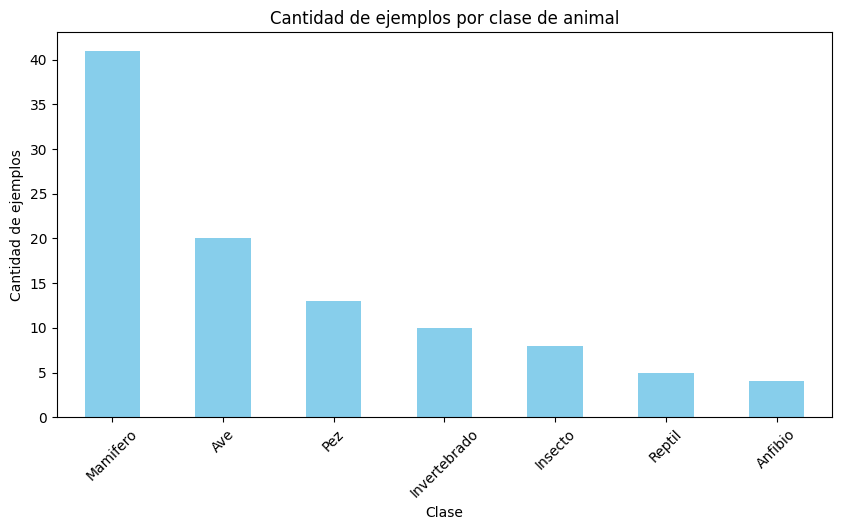

In [8]:
import matplotlib.pyplot as plt

# graficamos animales por clase
animales_por_clase = df_zoo["Clase"].value_counts()

plt.figure(figsize=(10,5))
animales_por_clase.plot(kind='bar', color='skyblue')
plt.title("Cantidad de ejemplos por clase de animal")
plt.xlabel("Clase")
plt.ylabel("Cantidad de ejemplos")
plt.xticks(rotation=45)
plt.show()

In [9]:
# entrenamiento para mamiferos
X = df_zoo.drop(columns=["animal", "Clase"]).astype(float).values
y = (df_zoo["Clase"] == "Mamifero").astype(int).values

p = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)

p.fit(X, y)
y_pred = p.predict(X)

cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS PARA MAMIFEROS--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# análisis de los pesos
pesos = p.w_
print("--------------------ANÁLISIS DE LOS PESOS--------------------")
columnas = df_zoo.drop(columns=["animal", "Clase"]).columns
for nombre, peso in zip(columnas, pesos):
    print(f"{nombre} -> {peso:.3f}")

# Los pesos positivos grandes indican que favorece la predicción de mamífero
# Los pesos negativos grandes indican que esa característica no es típica de los mamíferos

# análsis con iteraciones independientes
for seed in [1, 5, 42]:
    p = ClassPerceptron.Perceptron(alpha=0.1, n_iter=1000, random_state=seed)
    p.fit(X, y)
    print(f"--------------------PESOS EN ESTADOS RANDOM, SEED {seed}--------------------")
    for nombre, peso in zip(columnas, p.w_):
        print(f"{nombre} -> {peso:.3f}")

--------------------RESULTADOS PARA MAMIFEROS--------------------
Cantidad de Aciertos: 101 - Porcentaje de Precisión: 100.00%
--------------------ANÁLISIS DE LOS PESOS--------------------
Tiene_Pelo -> 0.729
Tiene_Plumas -> -0.531
Nace_de_huevo -> -0.701
Toma_Leche -> 0.742
Vuela -> -0.120
Acuatico -> -0.083
Depredador -> -0.368
Dentado -> 0.840
Vertebrado -> 0.004
Respira -> 0.452
Venenoso -> -0.739
Tiene_Aletas -> -0.025
Cant_Patas -> -0.026
Tiene_Cola -> 0.103
Domestico -> -0.163
Tamano_Gato -> 0.291
--------------------PESOS EN ESTADOS RANDOM, SEED 1--------------------
Tiene_Pelo -> 0.617
Tiene_Plumas -> -0.180
Nace_de_huevo -> -0.900
Toma_Leche -> 0.602
Vuela -> -0.453
Acuatico -> -0.308
Depredador -> -0.314
Dentado -> 0.346
Vertebrado -> 0.197
Respira -> 0.239
Venenoso -> -0.281
Tiene_Aletas -> 0.285
Cant_Patas -> -0.096
Tiene_Cola -> 0.378
Domestico -> -0.473
Tamano_Gato -> 0.370
--------------------PESOS EN ESTADOS RANDOM, SEED 5--------------------
Tiene_Pelo -> 0.522
Tiene_

In [10]:
# entrenamiento para reptiles
X = df_zoo.drop(columns=["animal", "Clase"]).astype(float).values
y = (df_zoo["Clase"] == "Reptil").astype(int).values

p = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)

p.fit(X, y)
y_pred = p.predict(X)

cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS PARA REPTILES--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# análisis de los pesos
pesos = p.w_
print("--------------------ANÁLISIS DE LOS PESOS--------------------")
columnas = df_zoo.drop(columns=["animal", "Clase"]).columns
for nombre, peso in zip(columnas, pesos):
    print(f"{nombre} -> {peso:.3f}")

# Los pesos positivos grandes indican que favorece la predicción de reptiles
# Los pesos negativos grandes indican que esa característica no es típica de los reptiles

# análsis con iteraciones independientes
for seed in [1, 5, 42]:
    p = ClassPerceptron.Perceptron(alpha=0.1, n_iter=1000, random_state=seed)
    p.fit(X, y)
    print(f"--------------------PESOS EN ESTADOS RANDOM, SEED {seed}--------------------")
    for nombre, peso in zip(columnas, p.w_):
        print(f"{nombre} -> {peso:.3f}")

--------------------RESULTADOS PARA REPTILES--------------------
Cantidad de Aciertos: 101 - Porcentaje de Precisión: 100.00%
--------------------ANÁLISIS DE LOS PESOS--------------------
Tiene_Pelo -> -1.158
Tiene_Plumas -> -0.802
Nace_de_huevo -> -0.173
Toma_Leche -> -1.090
Vuela -> -0.685
Acuatico -> -0.463
Depredador -> -0.031
Dentado -> -0.051
Vertebrado -> 0.495
Respira -> 0.127
Venenoso -> 0.329
Tiene_Aletas -> -0.765
Cant_Patas -> -0.102
Tiene_Cola -> 0.351
Domestico -> 0.033
Tamano_Gato -> 0.213
--------------------PESOS EN ESTADOS RANDOM, SEED 1--------------------
Tiene_Pelo -> -1.383
Tiene_Plumas -> -1.980
Nace_de_huevo -> -0.200
Toma_Leche -> -1.598
Vuela -> -1.053
Acuatico -> -1.408
Depredador -> -0.114
Dentado -> -0.254
Vertebrado -> 0.997
Respira -> -0.061
Venenoso -> 0.419
Tiene_Aletas -> -1.015
Cant_Patas -> -0.296
Tiene_Cola -> 1.378
Domestico -> -0.473
Tamano_Gato -> 0.270
--------------------PESOS EN ESTADOS RANDOM, SEED 5--------------------
Tiene_Pelo -> -1.278
T

In [11]:
# entrenamiento para aves
X = df_zoo.drop(columns=["animal", "Clase"]).astype(float).values
y = (df_zoo["Clase"] == "Ave").astype(int).values

p = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)

p.fit(X, y)
y_pred = p.predict(X)

cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS PARA AVES--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# análisis de los pesos
pesos = p.w_
print("--------------------ANÁLISIS DE LOS PESOS--------------------")
columnas = df_zoo.drop(columns=["animal", "Clase"]).columns
for nombre, peso in zip(columnas, pesos):
    print(f"{nombre} -> {peso:.3f}")

# Los pesos positivos grandes indican que favorece la predicción de aves
# Los pesos negativos grandes indican que esa característica no es típica de las aves

# análsis con iteraciones independientes
for seed in [1, 5, 42]:
    p = ClassPerceptron.Perceptron(alpha=0.1, n_iter=1000, random_state=seed)
    p.fit(X, y)
    print(f"--------------------PESOS EN ESTADOS RANDOM, SEED {seed}--------------------")
    for nombre, peso in zip(columnas, p.w_):
        print(f"{nombre} -> {peso:.3f}")

--------------------RESULTADOS PARA AVES--------------------
Cantidad de Aciertos: 101 - Porcentaje de Precisión: 100.00%
--------------------ANÁLISIS DE LOS PESOS--------------------
Tiene_Pelo -> -0.795
Tiene_Plumas -> 0.634
Nace_de_huevo -> -0.416
Toma_Leche -> -0.206
Vuela -> 0.670
Acuatico -> -0.217
Depredador -> -0.122
Dentado -> -0.599
Vertebrado -> 0.168
Respira -> 0.109
Venenoso -> -0.104
Tiene_Aletas -> -0.364
Cant_Patas -> -0.182
Tiene_Cola -> 0.474
Domestico -> 0.054
Tamano_Gato -> 0.206
--------------------PESOS EN ESTADOS RANDOM, SEED 1--------------------
Tiene_Pelo -> -0.283
Tiene_Plumas -> 0.620
Nace_de_huevo -> -0.300
Toma_Leche -> -0.398
Vuela -> -0.053
Acuatico -> -0.408
Depredador -> -0.114
Dentado -> -0.454
Vertebrado -> -0.003
Respira -> 0.139
Venenoso -> -0.081
Tiene_Aletas -> 0.085
Cant_Patas -> -0.096
Tiene_Cola -> 0.478
Domestico -> -0.273
Tamano_Gato -> 0.070
--------------------PESOS EN ESTADOS RANDOM, SEED 5--------------------
Tiene_Pelo -> -0.478
Tiene_P

## Ejercicio 7

El archivo **automobile_simple.csv** contiene 11 atributos de automóviles de un total de 205 registros. Es una versión modificada y simplificada del dataset disponible en el repositorio UCI [https://archive.ics.uci.edu/ml/datasets/Automobile](https://archive.ics.uci.edu/ml/datasets/Automobile). La siguiente tabla contiene una breve descripción de los atributos que contiene el archivo y caracterizan a cada vehículo.

| Atributo       | Descripción |
|----------------|-------------|
| make           | Marca: alfa-romero, audi, bmw, chevrolet… |
| fuel-type      | Tipo de combustible: diesel, gasolina. |
| num-of-doors   | Número de puertas: cuatro, dos. |
| body-style     | Tipo de carrocería: techo duro, wagon, sedán, hatchback, descapotable. |
| curb-weight    | Peso en vacío: numérico de 1488 a 4066. |
| engine-size    | Tamaño del motor: numérico de 61 a 326. |
| horsepower     | Potencia: numérico de 48 a 288. |
| city-mpg       | Rendimiento en ciudad (en millas por galón): numérico de 13 a 49. |
| highway-mpg    | Rendimiento en ruta (en millas por galón): numérico de 16 a 54. |
| price          | Precio en USD: numérico de 5118 a 45400. |
| volume         | Volumen del vehículo (alto x ancho x alto). |
| eco-rating     | Evaluación de la sostenibilidad ambiental del vehículo basado en su volumen, peso, consumo de combustible y tipo de combustible utilizado. |

1. Para cada atributo indique si es Discreto, Continuo, Nominal u Ordinal.
2. Elimine los registros que presenten valores faltantes
3. Calcule la matriz de correlación usando los atributos numéricos.
4. Realice el entrenamiento de un perceptrón para que aprenda a clasificar si un auto es ecológico. Tenga en cuenta los siguientes pasos:
   1. Utilice el atributo eco-rating para generar un nuevo atributo binario que determine si un auto es ecológico o no. Un auto es considerado ecológico si el valor de eco-rating supera la media de dicho atributo.
   2. Genere y compare 3 modelos utilizando diferentes normalizaciones (Sin normalizar, normalización lineal, normalización estándar.
   3. Teniendo en cuenta la matriz de correlación del punto c) repita el punto II) eliminando dos atributos fuertemente correlacionados (uno negativo y otro positivo). Compare y reflexione sobre los resultados obtenidos.

### Respuesta

1. Clasificacion:
- **Atributos Nominales (categorías sin orden)**
   - make (marca del auto, categorías sin orden).
   - fuel-type (tipos de combustible, diesel, gasolina, categorías sin jerarquía).
   - body-style (tipo de carrocería, sedán, hatchback, wagon, etc.).
- **Atributos Ordinales (categorías con orden implícito)**
   - num-of-doors (discreto y ordinal, dos puertas < cuatro puertas, existe un orden aunque limitado).
- **Atributos Continuos (valores numéricos en un rango real)**
   - eco-rating
   - curb-weight (peso en vacío en libras, numérico real aunque se represente en enteros).
   - engine-size (cilindrada).
   - horsepower (potencia).
   - city-mpg (rendimiento en ciudad).
   - highway-mpg (rendimiento en ruta).
   - price (precio en USD, numérico real).
   - volume (alto × ancho × largo, valores continuos).

4. **C-** Al eliminar atributos altamente correlacionados reducimos redundancia de información, podemos llegar a mejorar la generalización del modelo al generar menos ruido, podemos llegar a reducir la precisión pero aumentar la simpliciad y estabilidad del modelo.

In [12]:
df_autos = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\automobile-simple.csv")

# chequeamos que esté bien
print(df_autos.head(10))    # vemos las primeras filas
df_autos.shape    # vemos cantidad de filas y columnas
df_autos.info()     # vemos tipos de datos
df_autos.describe() # vemos estadísticas de las columnas numéricas
nulos = df_autos.isnull().sum()
porcentaje_nulos = (df_autos.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

          make fuel-type num-of-doors   body-style  curb-weight  engine-size  \
0  alfa-romero       gas          two  convertible         2548          130   
1  alfa-romero       gas          two  convertible         2548          130   
2  alfa-romero       gas          two    hatchback         2823          152   
3         audi       gas         four        sedan         2337          109   
4         audi       gas         four        sedan         2824          136   
5         audi       gas          two        sedan         2507          136   
6         audi       gas         four        sedan         2844          136   
7         audi       gas         four        wagon         2954          136   
8         audi       gas         four        sedan         3086          131   
9         audi       gas          two    hatchback         3053          131   

   horsepower  city-mpg  highway-mpg    price      volume  eco-rating  
0       111.0        21           27  13495.0  

In [13]:
# Elimine los registros que presenten valores faltantes

df_autos_limpio = df_autos.dropna()

print("--------------------DIMENSIONES--------------------")
print("Dimensiones originales:", df_autos.shape)
print("Dimensiones después de eliminar faltantes:", df_autos_limpio.shape)

--------------------DIMENSIONES--------------------
Dimensiones originales: (205, 12)
Dimensiones después de eliminar faltantes: (197, 12)


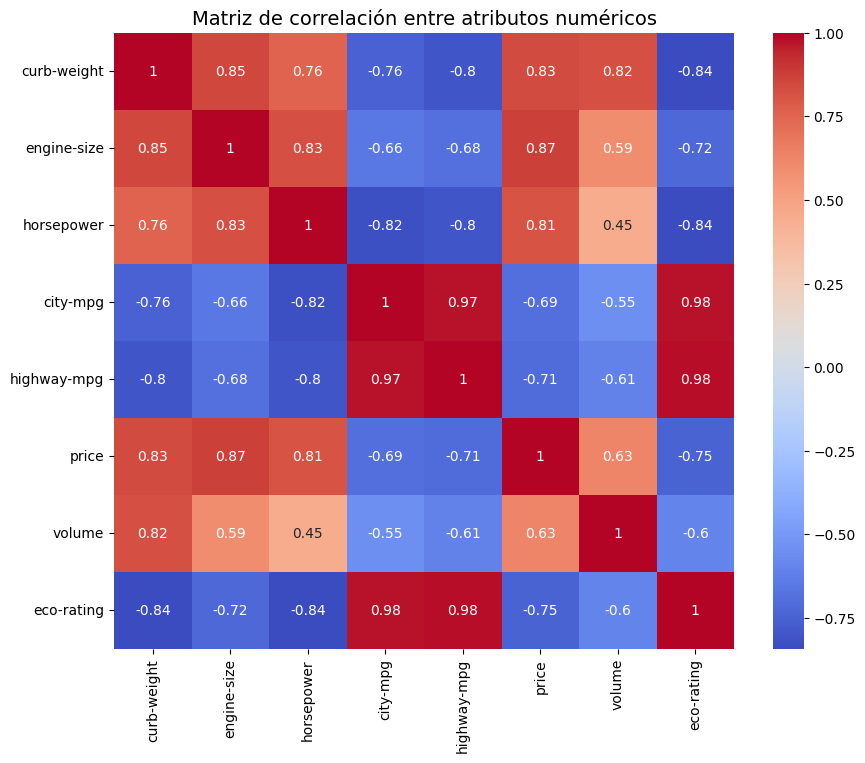

In [14]:
import seaborn as sns

# Calcule la matriz de correlación usando los atributos numéricos.

df_autos_limpio_num = df_autos_limpio.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(df_autos_limpio_num.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación entre atributos numéricos", fontsize=14)
plt.show()

In [15]:
# creamos columna binaria según criterio
df_autos_limpio = df_autos_limpio.copy()
eco_media = df_autos_limpio["eco-rating"].mean()
df_autos_limpio.loc[:, "eco-friendly"] = (df_autos_limpio["eco-rating"] > eco_media).astype(int)

X = df_autos_limpio.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).drop(
    columns=[
        "eco-rating",
        "eco-friendly"
    ]
).values
y = df_autos_limpio["eco-friendly"]

# Resultados sin Normalizar
p_sin_norm = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_sin_norm.fit(X, y)
y_pred = p_sin_norm.predict(X)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS SIN NORM--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# Resultados con Norm Lineal
lineal_scaler = MinMaxScaler()
X_lineal = lineal_scaler.fit_transform(X)
p_norm_lineal = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_norm_lineal.fit(X_lineal, y)
y_pred = p_norm_lineal.predict(X_lineal)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS NORM LINEAL--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# Resultados con Norm Standard
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)
p_norm_standard = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_norm_standard.fit(X_standard, y)
y_pred = p_norm_standard.predict(X_standard)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS NORM STANDARD--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

--------------------RESULTADOS SIN NORM--------------------
Cantidad de Aciertos: 173 - Porcentaje de Precisión: 87.82%
--------------------RESULTADOS NORM LINEAL--------------------
Cantidad de Aciertos: 197 - Porcentaje de Precisión: 100.00%
--------------------RESULTADOS NORM STANDARD--------------------
Cantidad de Aciertos: 197 - Porcentaje de Precisión: 100.00%


In [16]:
# Sacamos las cols Horsepower y City-mpg
# Hay alta correlación positiva entre Horsepower y Engine-size
# Hay alta correlación negativa entre Horsepower y City-mpg

X = df_autos_limpio.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).drop(
    columns=[
        "eco-rating",
        "eco-friendly",
        "horsepower",
        "city-mpg"
    ]
).values
y = df_autos_limpio["eco-friendly"]

# Resultados sin Normalizar
p_corr_sin_norm = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_corr_sin_norm.fit(X, y)
y_pred = p_corr_sin_norm.predict(X)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS SIN NORM--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# Resultados con Norm Lineal
lineal_scaler = MinMaxScaler()
X_lineal = lineal_scaler.fit_transform(X)
p_corr_norm_lineal = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_corr_norm_lineal.fit(X_lineal, y)
y_pred = p_corr_norm_lineal.predict(X_lineal)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS NORM LINEAL--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

# Resultados con Norm Standard
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)
p_corr_norm_standard = ClassPerceptron.Perceptron(
    alpha=0.1,
    n_iter=1000
)
p_corr_norm_standard.fit(X_standard, y)
y_pred = p_corr_norm_standard.predict(X_standard)
cant_aciertos = np.sum(y_pred == y)
precision = np.mean(y_pred == y)
print("--------------------RESULTADOS NORM STANDARD--------------------")
print(f"Cantidad de Aciertos: {cant_aciertos} - Porcentaje de Precisión: {precision*100:.2f}%")

--------------------RESULTADOS SIN NORM--------------------
Cantidad de Aciertos: 174 - Porcentaje de Precisión: 88.32%
--------------------RESULTADOS NORM LINEAL--------------------
Cantidad de Aciertos: 197 - Porcentaje de Precisión: 100.00%
--------------------RESULTADOS NORM STANDARD--------------------
Cantidad de Aciertos: 197 - Porcentaje de Precisión: 100.00%
